# Interpretable Machine Learning

----

The machine learning models we have trained in previous workshop have been *black-boxes*. We have no understanding of *why* our models have made their predictions and which of our input features are having the biggest influence on that outcome. It is often useful to understand what a model believes is important, particularly in chemistry, where this information can be used to guide molecular design and build trust in model performance. 

When interrogating model predictions we can look at either *Global* or *local* explanations. *Global* explanations tell us what features are generally important when making a predictions while *local* explanations give information about a specific predictions. We can do both using [SHAP](https://shap.readthedocs.io/en/latest/).

# *SH*apely *A*dditive ex*P*lanations (SHAP)

SHAP aims to explain model predictions by assigning each input feature a contribution score that described its affect on the observed prediction. To do this, a SHAP explainer must learn a *background* prediction value, $\phi_0$, based on the average predictions from the training data:

$$
\phi_0 \approx \frac{1}{N} \sum_{j=1}^{N} f(x_j)
$$

SHAP then explains why the prediction deviates from the baseline:


$$
f(x) = \phi_0 + \sum_{i=1}^{M} \phi_i
$$

where:

* $f(x)$ is the model's prediction for molecule $x$;
* $\phi_0$ is the baseline prediction;
* $M$ is the number of input features;
* $\phi_i$ is the SHAP value for feature $i$.

Positive SHAP values indicate features that push predictions *above* the baseline and negative SHAP values those that push predictions *below* the baseline. 

The difficulty is deciding how much of the deviation is attributed to each input feature. As a simple example, imagine an binary input representation with two features $A$ and $B$. If we only see a high prediction when both are present, how do we decide the contributions of both A and B as the prediction depends on them both? 

This is the purpose of Shapely values. For each feature, we must consider its contribution in combination with all other combinations of features:

$$
\phi_i =
\sum_{S \subseteq F\setminus{i}}
\frac{|S|!(M-|S|-1)!}{M!}
\left[
f(S\cup{i})-f(S)
\right]
$$

where:
* F is the complete set of features
* S is a sub set of features that does not contain feature $i$
* $M$ is the total number of features
* |S| is the number of features in the set

The important part is:
$$
f(S\cup{i})-f(S)
$$

which asks how much does the prediction change when feature $i$ is added. This is calculated for all possible combinations of input features, and is weighted by the term:
$$
\frac{|S|!(M-|S|-1)!}{M!}
$$

When working molecular fingerprints, we can generate SHAP values for each bit in our fingerprint:
$$
\phi = [\phi_1,\phi_2,\ldots,\phi_M]
$$

Essentially giving us a contribution score for each atomic environment in our fingerprint. Remember that fingerprinting is a one-way operation, so there is no way to generate molecular structure directly from a molecular fingerprint. It is possible however to generate bit information when generating the fingerprints that can be used to map each bit to its original substructure. If we keep track of this bit info, we can map the SHAP values back to our original input structure for *local* predictions. 

# Local SHAP Task
----
Use the function below to generate molecular fingerprints from the loaded dataset and train a Random Forest regressor. Notice the addition of the bit_info dictionary, which tracks which atom indices belong to each "on" bit in our fingerprint. We will use this later to map our SHAP explanations back to a molecular stucture. 

```
"""
bit_info : dict
    Mapping from fingerprint bit IDs to the atom environments that generated
    each bit in an RDKit Morgan fingerprint.

    Each dictionary key is a fingerprint bit ID (int). The corresponding value
    is a tuple of ``(atom_idx, radius)`` pairs, where:

    - ``atom_idx`` is the index of the central atom of the environment.
    - ``radius`` is the Morgan fingerprint radius at which that environment
      generated the bit.

    A bit may contain multiple ``(atom_idx, radius)`` entries because multiple
    atom environments can map to the same fingerprint bit.

    Example
    -------
    bit_info = {
        80: ((1, 0),),
        294: ((0, 1), (5, 1)),
        807: ((3, 2),)
    }
"""
```



In [1]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tdc.single_pred.adme import ADME
import pandas as pd

import numpy as np

def smiles_to_ecfp(smiles, radius=3, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap() # generates bit_info map
    ecfp = np.array(gen.GetFingerprint(mol, additionalOutput=ao))
    bit_info = ao.GetBitInfoMap()

    return ecfp, bit_info, mol

solubility_data = ADME('Solubility_AqSolDB')
solubility_split = solubility_data.get_split() # use predefined splits 

train_df = pd.concat([solubility_split["train"], solubility_split["valid"] ])
test_df = solubility_split["test"]

# convert dataframes to np arrays 
train_smiles = train_df["Drug"].to_numpy()
train_solubility = train_df["Y"].to_numpy()

test_smiles = test_df["Drug"].to_numpy()
test_solubility = test_df["Y"].to_numpy()


bits = [smiles_to_ecfp(x) for x in train_smiles]
fps = np.array([x[0] for x in bits]) 

Found local copy...
Loading...
Done!
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:43] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom without neighbors
[15:29:44] WARNING: not removing hydrogen atom withou

In [2]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=60)
print("traigin model")
model.fit(fps, train_solubility)



traigin model


RandomForestRegressor(max_depth=60)

Now write code to explain a prediction using SHAP. You will need to:
* Initialise the explainer using `shap.TreeExplainer(model)`
* Convert the test set into ECFPs using the new function
* Get shap values for predictions with `shap_values = explainer.shap_values(test_fps[[0]]) # any int you want`
* Select one molecule's SHAP values `mol_values = shap_values[0] # select the first entry`
* Convert those values into a dictionary that assigns each score to a bit number `shap_dict = {i: float(mol_values[i]) for i in range(len(mol_values))}`

In [3]:
test_bits = [smiles_to_ecfp(x) for x in test_smiles]
test_fps = np.array([x[0] for x in test_bits])
test_bit_info = [x[1] for x in test_bits]
test_mols = [x[2] for x in test_bits]

[15:32:24] WARNING: not removing hydrogen atom without neighbors
[15:32:24] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:25] WARNING: not removing hydrogen atom without neighbors
[15:32:26] WARNING: not r

In [4]:
import shap

print("training shap")
explainer = shap.TreeExplainer(model)

training shap


In [5]:
print(" getting values")

small_test_fp = test_fps[[0]] 
small_test_bi = test_bit_info[0]
small_test_mol = test_mols[0]

shap_values = explainer.shap_values(small_test_fp) # explain all fps

mol_values = shap_values[0]

shap_dict = {i: float(mol_values[i]) for i in range(len(mol_values))}


 getting values


Now we have a dictionary detailing the SHAP values arranged by bit number for all bits in our molecular fingerprint. We can assign these values as atom weights to our molecule and overlay a heat map on the molecular structure to show which parts of the molecule are influencing the prediction. 

To convert our SHAP values into atom weights we need to:
1. Initialise a numpy array to track our atom weights
2. Loop through each bit: environment pair in our molecule's bit_info dictionary
3. Extract the SHAP score for each bit
4. Loop through each (atom_idx, radius) pair in the environment
5. Add the SHAP score to each atom in the atom

Use the function below to convert the SHAP scores for you selected molecule to atom_weights 
 

In [19]:
def shap_scores_to_atom_weights(rdmol, bit_info, shap_scores):
    natoms = rdmol.GetNumAtoms()
    atom_weights = np.zeros((natoms,), dtype=np.float64)
    
    for bit_id, envs in bit_info.items():
        shap_score = shap_scores[bit_id]
        for atom_idx, radius in envs:
            atom_weights[atom_idx] += float(shap_score)
    return atom_weights.tolist()

atom_weights = shap_scores_to_atom_weights(small_test_mol, small_test_bi, shap_dict)

Now we can draw our molecule and visualise the atom_weights as a heatmap overlaid on the chemical structure. 

Use the function below to visualise your molecule using the atom weights you have just generated. 

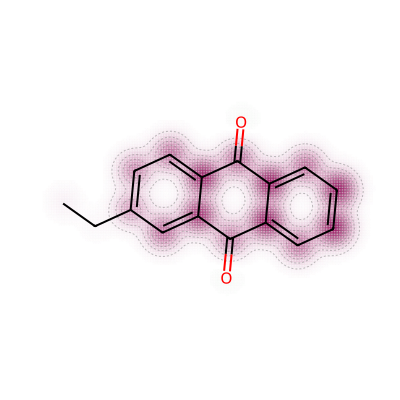

In [21]:
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import Image, display


def draw_molecule_with_heatmap(mol, atom_weights, size=(400, 400), legend=None):
    """
    Draw and display a molecule with a similarity-map heatmap based on atom weights.
    """
    AllChem.Compute2DCoords(mol)

    drawer = Draw.MolDraw2DCairo(*size)

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        atom_weights,
        draw2d=drawer,
        legend=legend,
        colormap="coolwarm"
    )

    drawer.FinishDrawing()

    display(Image(data=drawer.GetDrawingText()))

draw_molecule_with_heatmap(small_test_mol, atom_weights, size=(400, 400))

In [ ]:
def split_mol_with_weights(mol, atom_weights):
    """
    Split a Mol object into fragments and preserve atom weights.
    Returns a list of (Mol, fragment_atom_weights).
    """
    frag_indices = []
    frags = Chem.GetMolFrags(mol, asMols=True, fragsMolAtomMapping=frag_indices)  # return atom indices per fragment
    result = {}
    total_atoms = 0 # track which atoms we are on
    for frag, ind in zip(frags, frag_indices):
        frag_weights = [atom_weights[i] for i in ind]  # keep only relevant weights
        result[frag] = frag_weights
    return result




def bit_importance_to_atom_weight(mol, bit_info, bit_importance, product=False):
    natoms = mol.GetNumAtoms()
    atom_weights = np.zeros((natoms,), dtype=np.float64)

    for bit_id, envs in bit_info.items():
        if product:
            # if was are calculating for product, need to add length of reactant fp
            bit_id += 2048
        if bit_id not in bit_importance:
            continue
        imp = bit_importance[bit_id]
        for atom_idx, radius in envs:
            atom_weights[atom_idx] += float(imp)
    return atom_weights.tolist()


def reaction_smiles_to_heat_map(smiles, fingerprint, shap_values):
    weights = bit_importance_to_atom_weight(rfp_type.mol, rfp_type.bit_info, exp_map, product=product) # extract lime info per fp
    fragments = split_mol_with_weights(rfp_type.mol, weights) # split lime info per fragment
    imgs = [draw_molecule_with_heatmap(frag, weights) for frag, weights in fragments.items()] # draw fragments into lists of imgs
    return imgs


----
# 